# 1. data generate

In [1]:
import cv2

input_video_path = 'test_vid/230411BVK107.mp4'
output_video_path = 'output_video.mp4'
output_image_path = 'output_image.jpg'

video_capture = cv2.VideoCapture(input_video_path)

if not video_capture.isOpened():
    print("Error: Could not open video.")
    exit()

# 16 frame
frames = []
frame_count = 0

while frame_count < 16:
    ret, frame = video_capture.read()
    if not ret:
        break
    frames.append(frame)
    frame_count += 1

if frames:
    height, width, layers = frames[0].shape
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, 30.0, (width, height))

    for frame in frames:
        out.write(frame)

    out.release()

if frames:
    cv2.imwrite(output_image_path, frames[0])

video_capture.release()
cv2.destroyAllWindows()

print("Video and image saved successfully.")

Video and image saved successfully.


# 2. MODEL


In [2]:
from __future__ import division, absolute_import
import warnings
import torch
from torch import nn
from torch.nn import functional as F

__all__ = [
    'osnet_x1_0', 'osnet_x0_75', 'osnet_x0_5', 'osnet_x0_25', 'osnet_ibn_x1_0', 'osnet_x0_25_endocv'
]

pretrained_urls = {
    'osnet_x1_0':
    'https://drive.google.com/uc?id=1LaG1EJpHrxdAxKnSCJ_i0u-nbxSAeiFY',
    'osnet_x0_75':
    'https://drive.google.com/uc?id=1uwA9fElHOk3ZogwbeY5GkLI6QPTX70Hq',
    'osnet_x0_5':
    'https://drive.google.com/uc?id=16DGLbZukvVYgINws8u8deSaOqjybZ83i',
    'osnet_x0_25':
    'https://drive.google.com/uc?id=1rb8UN5ZzPKRc_xvtHlyDh-cSz88YX9hs',
    'osnet_ibn_x1_0':
    'https://drive.google.com/uc?id=1sr90V6irlYYDd4_4ISU2iruoRG8J__6l',
    'osnet_x0_25_endocv':
    'https://drive.google.com/uc?id=1W8mz6skAUmg33zMVpWn6woJym7xGygjh'
}


##########
# Basic layers
##########
class ConvLayer(nn.Module):
    """Convolution layer (conv + bn + relu)."""

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        stride=1,
        padding=0,
        groups=1,
        IN=False
    ):
        super(ConvLayer, self).__init__()
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size,
            stride=stride,
            padding=padding,
            bias=False,
            groups=groups
        )
        if IN:
            self.bn = nn.InstanceNorm2d(out_channels, affine=True)
        else:
            self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x


class Conv1x1(nn.Module):
    """1x1 convolution + bn + relu."""

    def __init__(self, in_channels, out_channels, stride=1, groups=1):
        super(Conv1x1, self).__init__()
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            1,
            stride=stride,
            padding=0,
            bias=False,
            groups=groups
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x


class Conv1x1Linear(nn.Module):
    """1x1 convolution + bn (w/o non-linearity)."""

    def __init__(self, in_channels, out_channels, stride=1):
        super(Conv1x1Linear, self).__init__()
        self.conv = nn.Conv2d(
            in_channels, out_channels, 1, stride=stride, padding=0, bias=False
        )
        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return x


class Conv3x3(nn.Module):
    """3x3 convolution + bn + relu."""

    def __init__(self, in_channels, out_channels, stride=1, groups=1):
        super(Conv3x3, self).__init__()
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            3,
            stride=stride,
            padding=1,
            bias=False,
            groups=groups
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x


class LightConv3x3(nn.Module):
    """Lightweight 3x3 convolution.

    1x1 (linear) + dw 3x3 (nonlinear).
    """

    def __init__(self, in_channels, out_channels):
        super(LightConv3x3, self).__init__()
        self.conv1 = nn.Conv2d(
            in_channels, out_channels, 1, stride=1, padding=0, bias=False
        )
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            3,
            stride=1,
            padding=1,
            bias=False,
            groups=out_channels
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.bn(x)
        x = self.relu(x)
        return x


##########
# Building blocks for omni-scale feature learning
##########
class ChannelGate(nn.Module):
    """A mini-network that generates channel-wise gates conditioned on input tensor."""

    def __init__(
        self,
        in_channels,
        num_gates=None,
        return_gates=False,
        gate_activation='sigmoid',
        reduction=16,
        layer_norm=False
    ):
        super(ChannelGate, self).__init__()
        if num_gates is None:
            num_gates = in_channels
        self.return_gates = return_gates
        self.global_avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Conv2d(
            in_channels,
            in_channels // reduction,
            kernel_size=1,
            bias=True,
            padding=0
        )
        self.norm1 = None
        if layer_norm:
            self.norm1 = nn.LayerNorm((in_channels // reduction, 1, 1))
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Conv2d(
            in_channels // reduction,
            num_gates,
            kernel_size=1,
            bias=True,
            padding=0
        )
        if gate_activation == 'sigmoid':
            self.gate_activation = nn.Sigmoid()
        elif gate_activation == 'relu':
            self.gate_activation = nn.ReLU(inplace=True)
        elif gate_activation == 'linear':
            self.gate_activation = None
        else:
            raise RuntimeError(
                "Unknown gate activation: {}".format(gate_activation)
            )

    def forward(self, x):
        input = x
        x = self.global_avgpool(x)
        x = self.fc1(x)
        if self.norm1 is not None:
            x = self.norm1(x)
        x = self.relu(x)
        x = self.fc2(x)
        if self.gate_activation is not None:
            x = self.gate_activation(x)
        if self.return_gates:
            return x
        return input * x


class OSBlock(nn.Module):
    """Omni-scale feature learning block."""

    def __init__(
        self,
        in_channels,
        out_channels,
        IN=False,
        bottleneck_reduction=4,
        **kwargs
    ):
        super(OSBlock, self).__init__()
        mid_channels = out_channels // bottleneck_reduction
        self.conv1 = Conv1x1(in_channels, mid_channels)
        self.conv2a = LightConv3x3(mid_channels, mid_channels)
        self.conv2b = nn.Sequential(
            LightConv3x3(mid_channels, mid_channels),
            LightConv3x3(mid_channels, mid_channels),
        )
        self.conv2c = nn.Sequential(
            LightConv3x3(mid_channels, mid_channels),
            LightConv3x3(mid_channels, mid_channels),
            LightConv3x3(mid_channels, mid_channels),
        )
        self.conv2d = nn.Sequential(
            LightConv3x3(mid_channels, mid_channels),
            LightConv3x3(mid_channels, mid_channels),
            LightConv3x3(mid_channels, mid_channels),
            LightConv3x3(mid_channels, mid_channels),
        )
        self.gate = ChannelGate(mid_channels)
        self.conv3 = Conv1x1Linear(mid_channels, out_channels)
        self.downsample = None
        if in_channels != out_channels:
            self.downsample = Conv1x1Linear(in_channels, out_channels)
        self.IN = None
        if IN:
            self.IN = nn.InstanceNorm2d(out_channels, affine=True)

    def forward(self, x):
        identity = x
        x1 = self.conv1(x)
        x2a = self.conv2a(x1)
        x2b = self.conv2b(x1)
        x2c = self.conv2c(x1)
        x2d = self.conv2d(x1)
        x2 = self.gate(x2a) + self.gate(x2b) + self.gate(x2c) + self.gate(x2d)
        x3 = self.conv3(x2)
        if self.downsample is not None:
            identity = self.downsample(identity)
        out = x3 + identity
        if self.IN is not None:
            out = self.IN(out)
        return F.relu(out)


##########
# Network architecture
##########
class OSNet(nn.Module):
    """Omni-Scale Network.

    Reference:
        - Zhou et al. Omni-Scale Feature Learning for Person Re-Identification. ICCV, 2019.
        - Zhou et al. Learning Generalisable Omni-Scale Representations
          for Person Re-Identification. TPAMI, 2021.
    """

    def __init__(
        self,
        num_classes,
        blocks,
        layers,
        channels,
        feature_dim=512,
        loss='softmax',
        IN=False,
        **kwargs
    ):
        super(OSNet, self).__init__()
        num_blocks = len(blocks)
        assert num_blocks == len(layers)
        assert num_blocks == len(channels) - 1
        self.loss = loss
        self.feature_dim = feature_dim

        # convolutional backbone
        self.conv1 = ConvLayer(3, channels[0], 7, stride=2, padding=3, IN=IN)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)
        self.conv2 = self._make_layer(
            blocks[0],
            layers[0],
            channels[0],
            channels[1],
            reduce_spatial_size=True,
            IN=IN
        )
        self.conv3 = self._make_layer(
            blocks[1],
            layers[1],
            channels[1],
            channels[2],
            reduce_spatial_size=True
        )
        self.conv4 = self._make_layer(
            blocks[2],
            layers[2],
            channels[2],
            channels[3],
            reduce_spatial_size=False
        )
        self.conv5 = Conv1x1(channels[3], channels[3])
        self.global_avgpool = nn.AdaptiveAvgPool2d(1)
        # fully connected layer
        self.fc = self._construct_fc_layer(
            self.feature_dim, channels[3], dropout_p=None
        )
        # identity classification layer
        self.classifier = nn.Linear(self.feature_dim, num_classes)

        self._init_params()

    def _make_layer(
        self,
        block,
        layer,
        in_channels,
        out_channels,
        reduce_spatial_size,
        IN=False
    ):
        layers = []

        layers.append(block(in_channels, out_channels, IN=IN))
        for i in range(1, layer):
            layers.append(block(out_channels, out_channels, IN=IN))

        if reduce_spatial_size:
            layers.append(
                nn.Sequential(
                    Conv1x1(out_channels, out_channels),
                    nn.AvgPool2d(2, stride=2)
                )
            )

        return nn.Sequential(*layers)

    def _construct_fc_layer(self, fc_dims, input_dim, dropout_p=None):
        if fc_dims is None or fc_dims < 0:
            self.feature_dim = input_dim
            return None

        if isinstance(fc_dims, int):
            fc_dims = [fc_dims]

        layers = []
        for dim in fc_dims:
            layers.append(nn.Linear(input_dim, dim))
            layers.append(nn.BatchNorm1d(dim))
            layers.append(nn.ReLU(inplace=True))
            if dropout_p is not None:
                layers.append(nn.Dropout(p=dropout_p))
            input_dim = dim

        self.feature_dim = fc_dims[-1]

        return nn.Sequential(*layers)

    def _init_params(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight, mode='fan_out', nonlinearity='relu'
                )
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def featuremaps(self, x):
        x = self.conv1(x)
        x = self.maxpool(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        return x

    def forward(self, x, return_featuremaps=False):
        x = self.featuremaps(x)
        if return_featuremaps:
            return x
        v = self.global_avgpool(x)
        v = v.view(v.size(0), -1)
        if self.fc is not None:
            v = self.fc(v)
        if not self.training:
            return v
        y = self.classifier(v)
        if self.loss == 'softmax':
            return y
        elif self.loss == 'triplet':
            return y, v
        else:
            raise KeyError("Unsupported loss: {}".format(self.loss))


def init_pretrained_weights(model, key=''):
    """Initializes model with pretrained weights.

    Layers that don't match with pretrained layers in name or size are kept unchanged.
    """
    import os
    import errno
    import gdown
    from collections import OrderedDict

    def _get_torch_home():
        ENV_TORCH_HOME = 'TORCH_HOME'
        ENV_XDG_CACHE_HOME = 'XDG_CACHE_HOME'
        DEFAULT_CACHE_DIR = '~/.cache'
        torch_home = os.path.expanduser(
            os.getenv(
                ENV_TORCH_HOME,
                os.path.join(
                    os.getenv(ENV_XDG_CACHE_HOME, DEFAULT_CACHE_DIR), 'torch'
                )
            )
        )
        return torch_home

    torch_home = _get_torch_home()
    model_dir = os.path.join(torch_home, 'checkpoints')
    try:
        os.makedirs(model_dir)
    except OSError as e:
        if e.errno == errno.EEXIST:
            # Directory already exists, ignore.
            pass
        else:
            # Unexpected OSError, re-raise.
            raise
    filename = key + '_imagenet.pth'
    cached_file = os.path.join(model_dir, filename)

    if not os.path.exists(cached_file):
      if key == 'osnet_x0_25_endocv':
        filename = key + '.pth'
        cached_file = os.path.join(model_dir, filename)
        gdown.download(pretrained_urls[key], cached_file, quiet=False)
      else:
        gdown.download(pretrained_urls[key], cached_file, quiet=False)

    state_dict = torch.load(cached_file)
    model_dict = model.state_dict()
    new_state_dict = OrderedDict()
    matched_layers, discarded_layers = [], []

    for k, v in state_dict.items():
        if k.startswith('module.'):
            k = k[7:] # discard module.

        if k in model_dict and model_dict[k].size() == v.size():
            new_state_dict[k] = v
            matched_layers.append(k)
        else:
            discarded_layers.append(k)

    model_dict.update(new_state_dict)
    model.load_state_dict(model_dict)

    if len(matched_layers) == 0:
        warnings.warn(
            'The pretrained weights from "{}" cannot be loaded, '
            'please check the key names manually '
            '(** ignored and continue **)'.format(cached_file)
        )
    else:
        print(
            'Successfully loaded imagenet pretrained weights from "{}"'.
            format(cached_file)
        )
        if len(discarded_layers) > 0:
            print(
                '** The following layers are discarded '
                'due to unmatched keys or layer size: {}'.
                format(discarded_layers)
            )


##########
# Instantiation
##########
def osnet_x1_0(num_classes=1000, pretrained=True, loss='softmax', **kwargs):
    # standard size (width x1.0)
    model = OSNet(
        num_classes,
        blocks=[OSBlock, OSBlock, OSBlock],
        layers=[2, 2, 2],
        channels=[64, 256, 384, 512],
        loss=loss,
        **kwargs
    )
    if pretrained:
        init_pretrained_weights(model, key='osnet_x1_0')
    return model


def osnet_x0_75(num_classes=1000, pretrained=True, loss='softmax', **kwargs):
    # medium size (width x0.75)
    model = OSNet(
        num_classes,
        blocks=[OSBlock, OSBlock, OSBlock],
        layers=[2, 2, 2],
        channels=[48, 192, 288, 384],
        loss=loss,
        **kwargs
    )
    if pretrained:
        init_pretrained_weights(model, key='osnet_x0_75')
    return model


def osnet_x0_5(num_classes=1000, pretrained=True, loss='softmax', **kwargs):
    # tiny size (width x0.5)
    model = OSNet(
        num_classes,
        blocks=[OSBlock, OSBlock, OSBlock],
        layers=[2, 2, 2],
        channels=[32, 128, 192, 256],
        loss=loss,
        **kwargs
    )
    if pretrained:
        init_pretrained_weights(model, key='osnet_x0_5')
    return model


def osnet_x0_25(num_classes=1000, pretrained=True, loss='softmax', **kwargs):
    # very tiny size (width x0.25)
    model = OSNet(
        num_classes,
        blocks=[OSBlock, OSBlock, OSBlock],
        layers=[2, 2, 2],
        channels=[16, 64, 96, 128],
        loss=loss,
        **kwargs
    )
    if pretrained:
        init_pretrained_weights(model, key='osnet_x0_25')
    return model


def osnet_x0_25_endocv(num_classes=1000, pretrained=True, loss='softmax', **kwargs):
    # very tiny size (width x0.25)
    model = OSNet(
        num_classes,
        blocks=[OSBlock, OSBlock, OSBlock],
        layers=[2, 2, 2],
        channels=[16, 64, 96, 128],
        loss=loss,
        **kwargs
    )
    if pretrained:
        init_pretrained_weights(model, key='osnet_x0_25_endocv')
    return model


def osnet_ibn_x1_0(
    num_classes=1000, pretrained=True, loss='softmax', **kwargs
):
    # standard size (width x1.0) + IBN layer
    # Ref: Pan et al. Two at Once: Enhancing Learning and Generalization Capacities via IBN-Net. ECCV, 2018.
    model = OSNet(
        num_classes,
        blocks=[OSBlock, OSBlock, OSBlock],
        layers=[2, 2, 2],
        channels=[64, 256, 384, 512],
        loss=loss,
        IN=True,
        **kwargs
    )
    if pretrained:
        init_pretrained_weights(model, key='osnet_ibn_x1_0')
    return model

# 3. Ket hop

In [49]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import cv2
import numpy as np
import os

# ================== 1. Define C3D ==================
class C3D(nn.Module):
    def __init__(self):
        super(C3D, self).__init__()
        self.conv1 = nn.Conv3d(3, 64, kernel_size=(3, 3, 3), stride=1, padding=1)
        self.pool1 = nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2))
        self.conv2 = nn.Conv3d(64, 128, kernel_size=(3, 3, 3), stride=1, padding=1)
        self.pool2 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))
        self.conv3a = nn.Conv3d(128, 256, kernel_size=(3, 3, 3), stride=1, padding=1)
        self.conv3b = nn.Conv3d(256, 256, kernel_size=(3, 3, 3), stride=1, padding=1)
        self.pool3 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))
        
        # Adaptive Pooling
        self.global_pool = nn.AdaptiveAvgPool3d((1, 1, 1))  # (B, C, 1, 1, 1)
        self.fc6 = nn.Linear(256, 256)  # Match OSNet feature size

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.pool3(torch.relu(self.conv3b(torch.relu(self.conv3a(x)))))
        
        feature_map = x
        x = self.global_pool(x)  # (B, C, 1, 1, 1)
        x = x.view(x.size(0), -1)  # (B, C)
        x = self.fc6(x)
        return x, feature_map

# ================== 2. C3D + OSNet ==================
class ReIDModel(nn.Module):
    def __init__(self):
        super(ReIDModel, self).__init__()
        self.osnet = osnet_x0_25(pretrained=True)  # Load OSNet
        self.c3d = C3D()  # Load C3D
        self.fusion = nn.Linear(384, 256) # 128 + 256
        # self.fusion = nn.Linear(512 + 256, 256)  # OSNet (512) và C3D (256)

    def forward(self, img, video_clip):
        osnet_feat_map = self.osnet.featuremaps(img)  # Feature map OSNet
        osnet_feat = self.osnet.global_avgpool(osnet_feat_map)  # Global Pooling
        osnet_feat = osnet_feat.view(osnet_feat.size(0), -1)  # Vectorize
        
        c3d_feat, c3d_feat_map = self.c3d(video_clip)  # Feature map C3D
        print("OSNet feature shape:", osnet_feat.shape)
        print("C3D feature shape:", c3d_feat.shape)

        combined_feat = torch.cat((osnet_feat, c3d_feat), dim=1)  # Combine OSNet and C3D features
        final_feat = self.fusion(combined_feat)  # Fully connected

        return final_feat, osnet_feat_map, c3d_feat_map

# ================== 3. Load model ==================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
reid_model = ReIDModel().to(device)
reid_model.eval()

# ================== 4. Chuẩn bị dữ liệu ==================
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128, 256)),
    transforms.ToTensor()
])

img_path = "output_image.jpg"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = transform(img).unsqueeze(0).to(device)

video_path = "output_video.mp4"
cap = cv2.VideoCapture(video_path)
frame_buffer = []

while len(frame_buffer) < 16:
    ret, frame = cap.read()
    if not ret:
        break
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # RGB
    frame_resized = cv2.resize(frame, (112, 112))  # Resize 112x112
    frame_tensor = torch.tensor(frame_resized).permute(2, 0, 1).unsqueeze(0).float().to(device) / 255.0
    frame_buffer.append(frame_tensor)

cap.release()

while len(frame_buffer) < 16:
    frame_buffer.append(frame_buffer[-1])

# To tensor 5D: (B=1, C=3, T=16, H=112, W=112)
video_clip = torch.cat(frame_buffer, dim=0)  # (16, 3, 112, 112)
video_clip = video_clip.permute(1, 0, 2, 3).unsqueeze(0).to(device)  # (1, 3, 16, 112, 112)

# ================== 5. Chạy model Re-ID ==================
feature_vector, osnet_feat_map, c3d_feat_map = reid_model(img_resized, video_clip)

print("Feature vector shape:", feature_vector.shape)  
print("OSNet Feature Map shape:", osnet_feat_map.shape)  
print("C3D Feature Map shape:", c3d_feat_map.shape)


/tmp/ipykernel_25999/757664991.py:489: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(cached_file)


Successfully loaded imagenet pretrained weights from "/home/ekai10/.cache/torch/checkpoints/osnet_x0_25_imagenet.pth"
OSNet feature shape: torch.Size([1, 128])
C3D feature shape: torch.Size([1, 256])
Feature vector shape: torch.Size([1, 256])
OSNet Feature Map shape: torch.Size([1, 128, 8, 16])
C3D Feature Map shape: torch.Size([1, 256, 4, 14, 14])


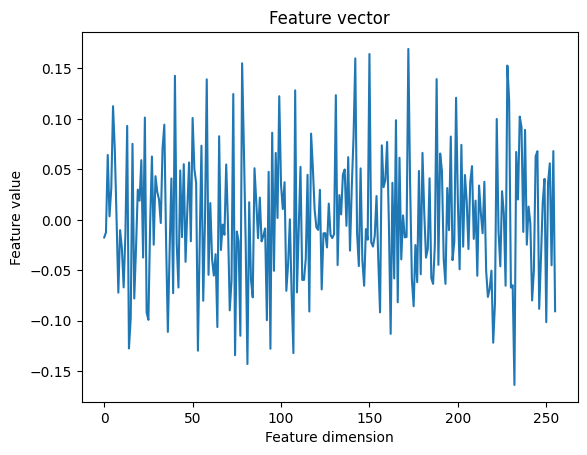

In [40]:
import matplotlib.pyplot as plt
plt.plot(feature_vector.squeeze().detach().cpu().numpy())
plt.title("Feature vector")
plt.xlabel("Feature dimension")
plt.ylabel("Feature value")
plt.show()

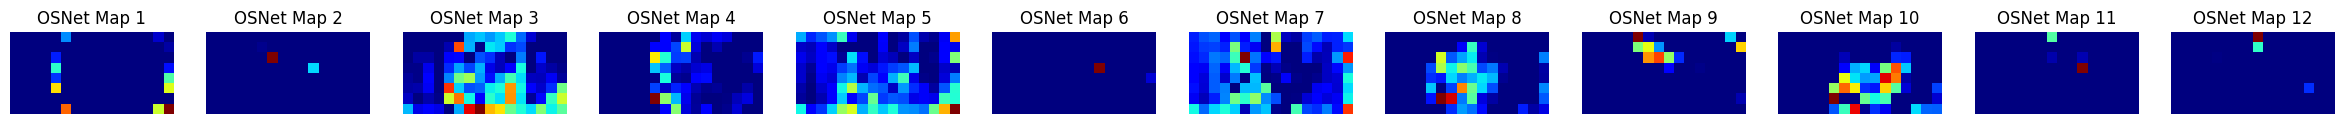

In [48]:
# OSNET
import matplotlib.pyplot as plt
import torch
import numpy as np

# First 6-channel feature map
num_channels = 12
fig, axes = plt.subplots(1, num_channels, figsize=(30, 10))

# Tensor to numpy
osnet_feat_map = osnet_feat_map.squeeze(0).cpu().detach().numpy()  # (C, H, W)

for i in range(num_channels):
    axes[i].imshow(osnet_feat_map[i], cmap='jet')
    axes[i].axis("off")
    axes[i].set_title(f"OSNet Map {i+1}")

plt.show()

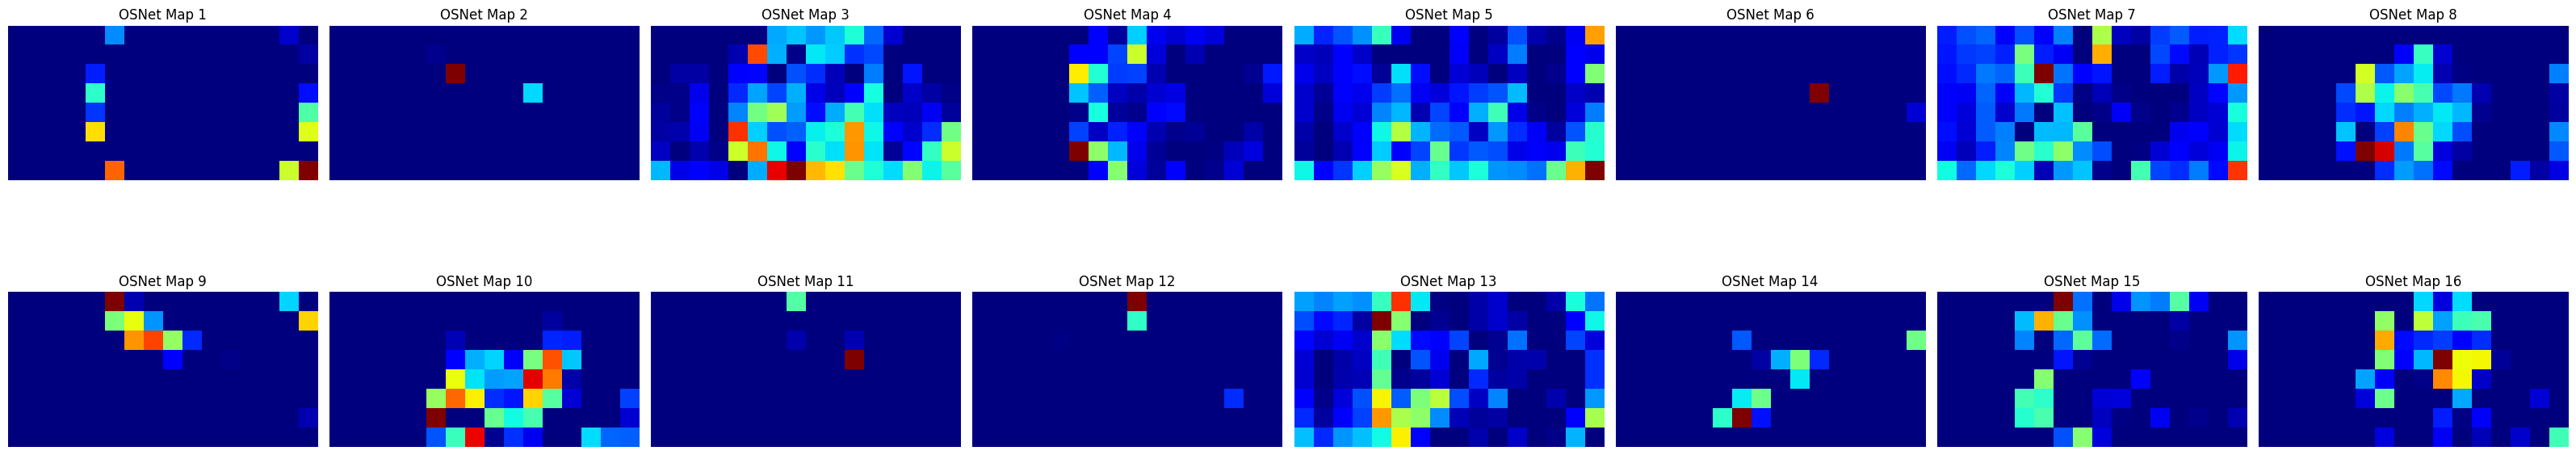

In [50]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Giả sử osnet_feat_map đã được thu thập từ mô hình
# Số lượng kênh
num_channels = 16

# Tạo figure với 2 hàng, mỗi hàng 8 hình
fig, axes = plt.subplots(2, 8, figsize=(32, 8))

# Chuyển tensor thành numpy
osnet_feat_map = osnet_feat_map.squeeze(0).cpu().detach().numpy()  # (C, H, W)

# Vẽ feature map
for i in range(num_channels):
    ax = axes[i // 8, i % 8]  # Xác định vị trí subplot
    ax.imshow(osnet_feat_map[i], cmap='jet')
    ax.axis("off")
    ax.set_title(f"OSNet Map {i+1}")

# Ẩn các subplot không sử dụng
for j in range(num_channels, 16):  # 16 là tổng số subplot
    axes[j // 8, j % 8].axis("off")

plt.tight_layout()
plt.show()

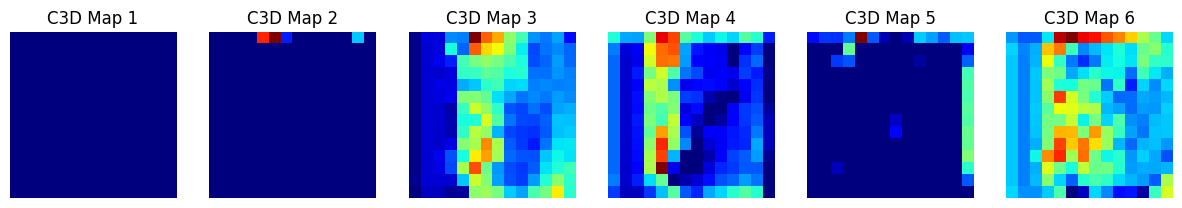

In [22]:
# C3D
# Chọn một frame nhất định trong video clip (ví dụ: frame giữa)
t = c3d_feat_map.shape[2] // 2  # Lấy frame giữa

fig, axes = plt.subplots(1, num_channels, figsize=(15, 5))

# Chuyển tensor về numpy
c3d_feat_map = c3d_feat_map.squeeze(0).cpu().detach().numpy()  # (C, T, H, W)

for i in range(num_channels):
    axes[i].imshow(c3d_feat_map[i, t], cmap='jet')  # Lấy frame tại thời điểm t
    axes[i].axis("off")
    axes[i].set_title(f"C3D Map {i+1}")

plt.show()


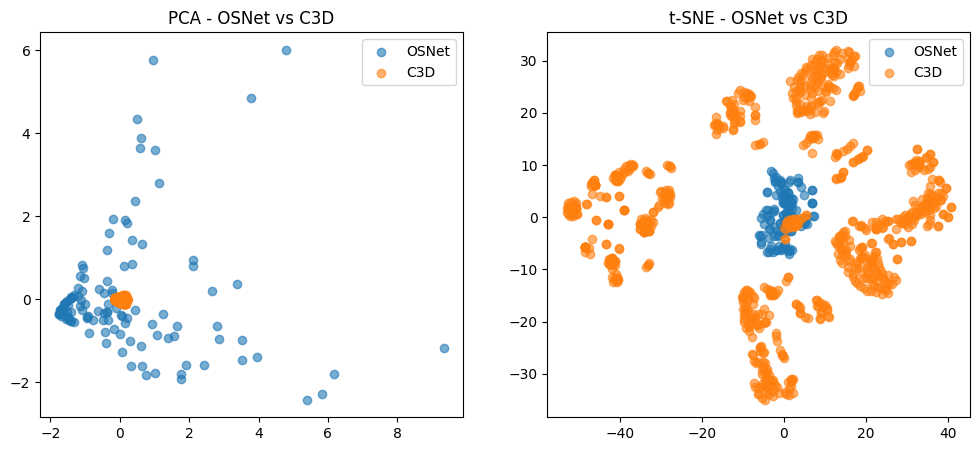

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Chuyển feature map về numpy nếu còn là tensor
if isinstance(osnet_feat_map, torch.Tensor):
    osnet_feat_map = osnet_feat_map.cpu().detach().numpy()
if isinstance(c3d_feat_map, torch.Tensor):
    c3d_feat_map = c3d_feat_map.cpu().detach().numpy()

# Reshape feature map
osnet_feat_flat = osnet_feat_map.reshape(osnet_feat_map.shape[0], -1).T  # (H*W, C1)
c3d_feat_flat = c3d_feat_map.reshape(c3d_feat_map.shape[0], -1).T  # (T*H*W, C2)

# PCA để giảm chiều xuống 2D
pca_osnet = PCA(n_components=2).fit_transform(osnet_feat_flat)
pca_c3d = PCA(n_components=2).fit_transform(c3d_feat_flat)

# t-SNE để xem không gian feature
tsne_osnet = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(osnet_feat_flat)
tsne_c3d = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(c3d_feat_flat)

# Vẽ đồ thị
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(pca_osnet[:, 0], pca_osnet[:, 1], label="OSNet", alpha=0.6)
axes[0].scatter(pca_c3d[:, 0], pca_c3d[:, 1], label="C3D", alpha=0.6)
axes[0].set_title("PCA - OSNet vs C3D")
axes[0].legend()

axes[1].scatter(tsne_osnet[:, 0], tsne_osnet[:, 1], label="OSNet", alpha=0.6)
axes[1].scatter(tsne_c3d[:, 0], tsne_c3d[:, 1], label="C3D", alpha=0.6)
axes[1].set_title("t-SNE - OSNet vs C3D")
axes[1].legend()

plt.show()


In [35]:
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr

# Chuyển feature vector cuối cùng về numpy
print("Feature Vector Shape:", feature_vector.shape)


if isinstance(feature_vector, torch.Tensor):
    feature_vector = feature_vector.cpu().detach().numpy()

print("Feature Vector Type:", type(feature_vector))
print("Feature Vector Shape:", feature_vector.shape)

# Giảm số hàng của C3D về 128 bằng cách lấy trung bình
factor = c3d_feat_flat.shape[0] // 128  # = 784 // 128 = 6
c3d_downsampled = c3d_feat_flat[:128 * factor].reshape(128, factor, -1).mean(axis=1)  # (128, 256)

# c3d_downsampled = c3d_feat_flat.reshape(128, -1, c3d_feat_flat.shape[1]).mean(axis=1)

# Kiểm tra kích thước
print("OSNet Shape:", osnet_feat_flat.shape)  # (128, C1)
print("C3D Downsampled Shape:", c3d_downsampled.shape)  # (128, C2)

# Ghép OSNet + C3D
combined_feat_map = np.concatenate((osnet_feat_flat, c3d_downsampled), axis=1)  # (128, C1+C2)

# Feature map sau khi kết hợp OSNet + C3D
# combined_feat_map = np.concatenate((osnet_feat_flat, c3d_feat_flat), axis=1)  # (N, C1+C2)

# Tính trung bình theo chiều không gian để có feature đại diện
osnet_feat_avg = osnet_feat_flat.mean(axis=0)  # (C1,)
c3d_feat_avg = c3d_feat_flat.mean(axis=0)  # (C2,)
combined_feat_avg = combined_feat_map.mean(axis=0)  # (C1+C2,)

# Cosine Similarity
cos_osnet = 1 - cosine(osnet_feat_avg, feature_vector)
cos_c3d = 1 - cosine(c3d_feat_avg, feature_vector)
cos_combined = 1 - cosine(combined_feat_avg, feature_vector)

# Pearson Correlation
pearson_osnet, _ = pearsonr(osnet_feat_avg, feature_vector)
pearson_c3d, _ = pearsonr(c3d_feat_avg, feature_vector)
pearson_combined, _ = pearsonr(combined_feat_avg, feature_vector)

print(f"Cosine Similarity - OSNet vs Feature Vector: {cos_osnet:.4f}")
print(f"Cosine Similarity - C3D vs Feature Vector: {cos_c3d:.4f}")
print(f"Cosine Similarity - Combined vs Feature Vector: {cos_combined:.4f}")

print(f"Pearson Correlation - OSNet vs Feature Vector: {pearson_osnet:.4f}")
print(f"Pearson Correlation - C3D vs Feature Vector: {pearson_c3d:.4f}")
print(f"Pearson Correlation - Combined vs Feature Vector: {pearson_combined:.4f}")


Feature Vector Shape: (256,)
Feature Vector Type: <class 'numpy.ndarray'>
Feature Vector Shape: (256,)
OSNet Shape: (128, 128)
C3D Downsampled Shape: (128, 256)


ValueError: shapes (128,) and (256,) not aligned: 128 (dim 0) != 256 (dim 0)

In [25]:
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr

# Flatten feature maps
osnet_feat_flat = osnet_feat_map.squeeze(0).mean(dim=(1, 2)).cpu().detach().numpy()  # (C1,)
c3d_feat_flat = c3d_feat_map.squeeze(0).mean(dim=(1, 2, 3)).cpu().detach().numpy()  # (C2,)
feature_vector = feature_vector.squeeze(0).cpu().detach().numpy()  # (D,)

# Cosine Similarity
cos_osnet = 1 - cosine(osnet_feat_flat, feature_vector)
cos_c3d = 1 - cosine(c3d_feat_flat, feature_vector)

# Pearson Correlation
pearson_osnet, _ = pearsonr(osnet_feat_flat, feature_vector)
pearson_c3d, _ = pearsonr(c3d_feat_flat, feature_vector)

print(f"Cosine Similarity - OSNet vs Feature Vector: {cos_osnet:.4f}")
print(f"Cosine Similarity - C3D vs Feature Vector: {cos_c3d:.4f}")
print(f"Pearson Correlation - OSNet vs Feature Vector: {pearson_osnet:.4f}")
print(f"Pearson Correlation - C3D vs Feature Vector: {pearson_c3d:.4f}")


ValueError: cannot select an axis to squeeze out which has size not equal to one